# Description

It takes a GWAS that was imputed and postprocessed (using the PrediXcan scripts here https://github.com/hakyimlab/summary-gwas-imputation) on a random phenotype and verifies that the Manhattan and QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
GWAS_DIR <- file.path(
    GLS_NULL_SIMS_DIR,
    # "_pvalue",
    "harmonized_gwas"
)

In [6]:
GWAS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/harmonized_gwas"

In [7]:
title_prefix = "harmonized"

# Random pheno 0 (beta/se)

In [8]:
pheno_code <- "0"

## Load data

In [9]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [10]:
dim(gwas)

[1] 6746644      13

In [11]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.2889517,1.0604241,0.0699110,0.0659274,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.5954279,-0.5309869,-0.0350900,0.0660845,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.6391534,0.4688829,0.0270725,0.0577383,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.6949130,0.3921966,0.0182231,0.0464642,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.2624019,1.1207322,0.0752751,0.0671660,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.0370333,2.0853968,0.1530700,0.0734009,10000,NA


### Extract chromosome

In [12]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [13]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [14]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [15]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [16]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.4986333,0.2887069,6.470527e-09,1


In [17]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [18]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.4354188,0.4322442,0,8.18906


In [19]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [20]:
gwas_max_mlog_noninf

[1] 8.18906

In [21]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [22]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.001049111,1.001247,-4.90427,5.804119


In [23]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [24]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-2.627528e-05,0.03341668,-0.369534,0.384376


In [25]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [26]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.0295414,0.01580025,0.0136786,0.236104


## Manhattan plot

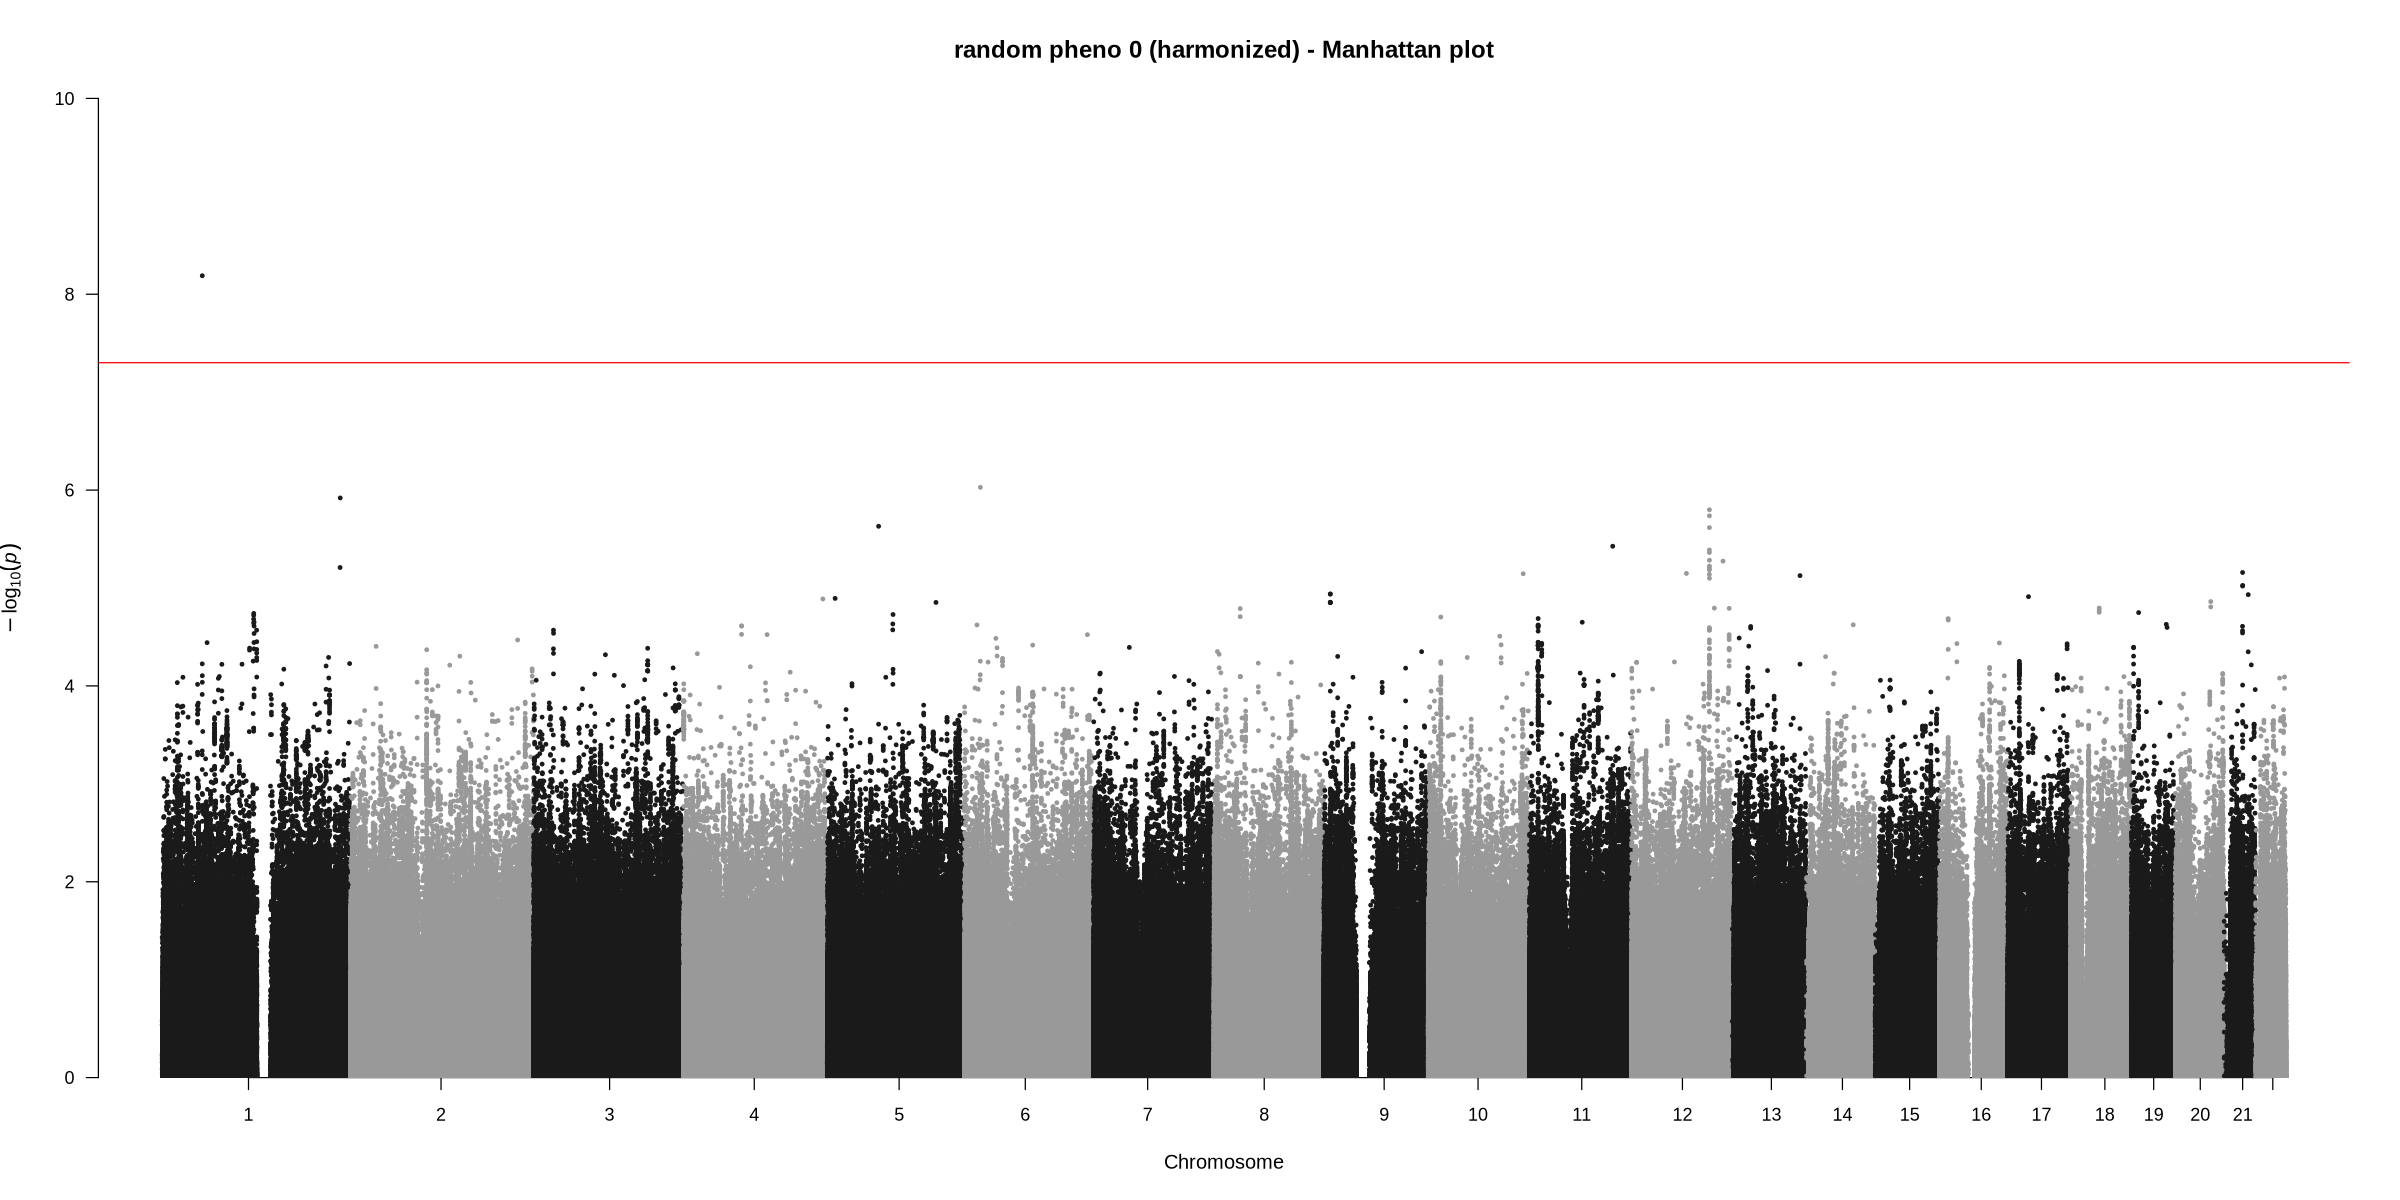

In [27]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

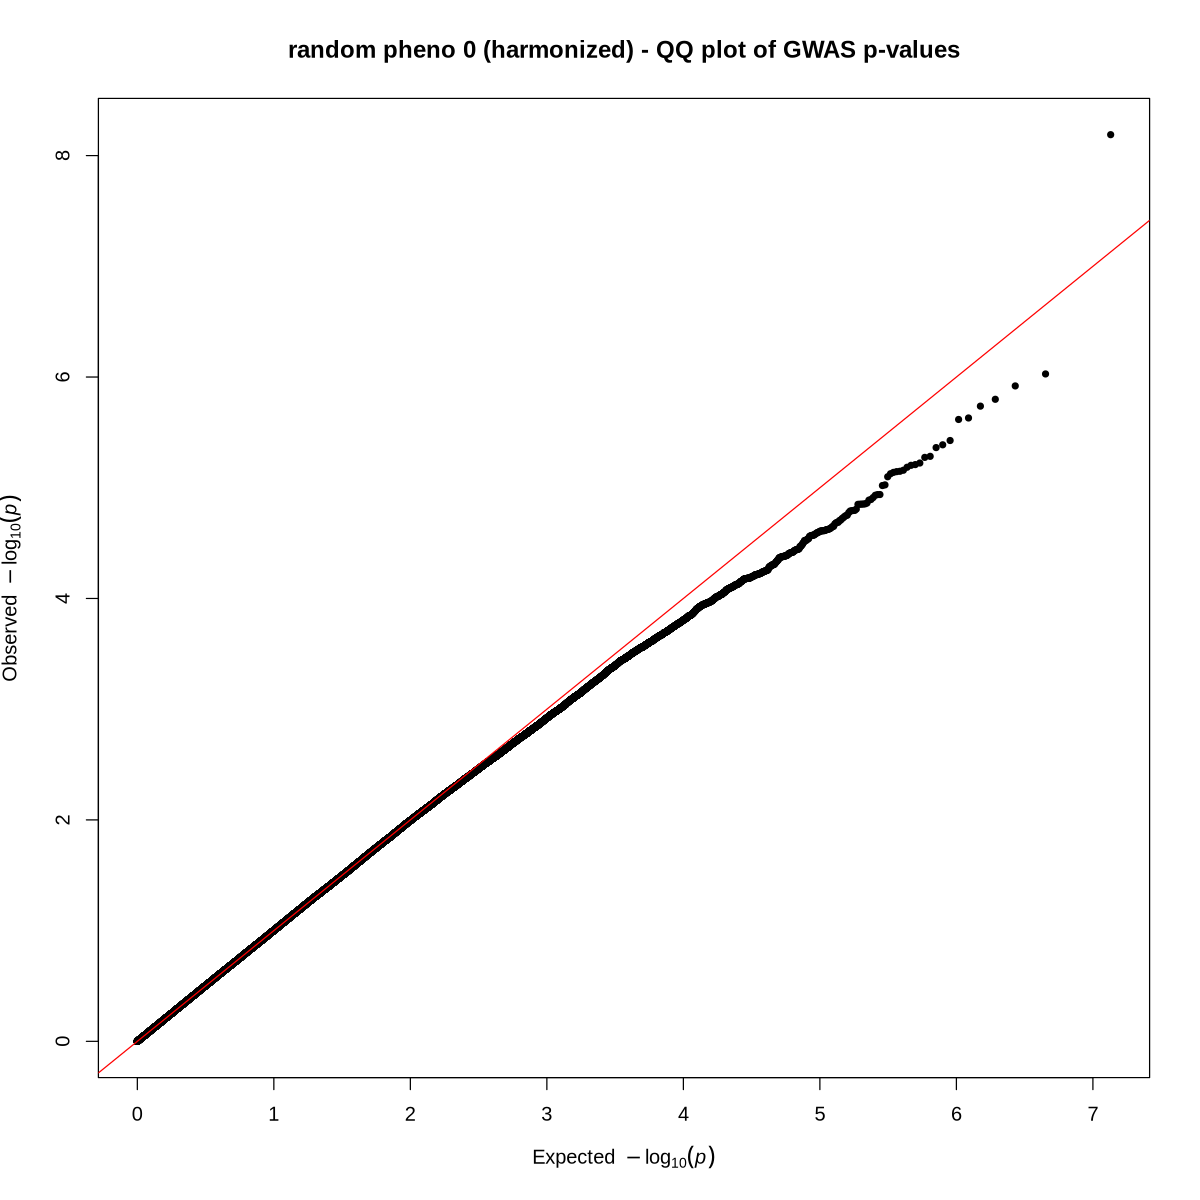

In [28]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 0 (pvalue)

This is a check with the previous run of the harmonization script that included the pvalue column.
The one at the top, labeld "beta/se", includes only those two columns, as suggested by the harmonization script (after finding GWAS pvalues with zeros).

In [8]:
pheno_code <- "0"

## Load data

In [9]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [10]:
dim(gwas)

[1] 6746644      13

In [11]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.288978,1.0603663,0.0699110,0.0659274,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.595439,-0.5309708,-0.0350900,0.0660845,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.639164,0.4688680,0.0270725,0.0577383,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.694922,0.3921844,0.0182231,0.0464642,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.262429,1.1206685,0.0752751,0.0671660,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.037059,2.0851135,0.1530700,0.0734009,10000,NA


### Extract chromosome

In [12]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [13]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [14]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [15]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [16]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.4986494,0.2886973,0,1


In [17]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [18]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
Inf,NaN,0,Inf


In [19]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [20]:
gwas_max_mlog_noninf

[1] 6

In [21]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [22]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.001050632,1.001161,-4.891638,14.97948


In [23]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [24]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-2.627528e-05,0.03341668,-0.369534,0.384376


In [25]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [26]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.0295414,0.01580025,0.0136786,0.236104


## Manhattan plot

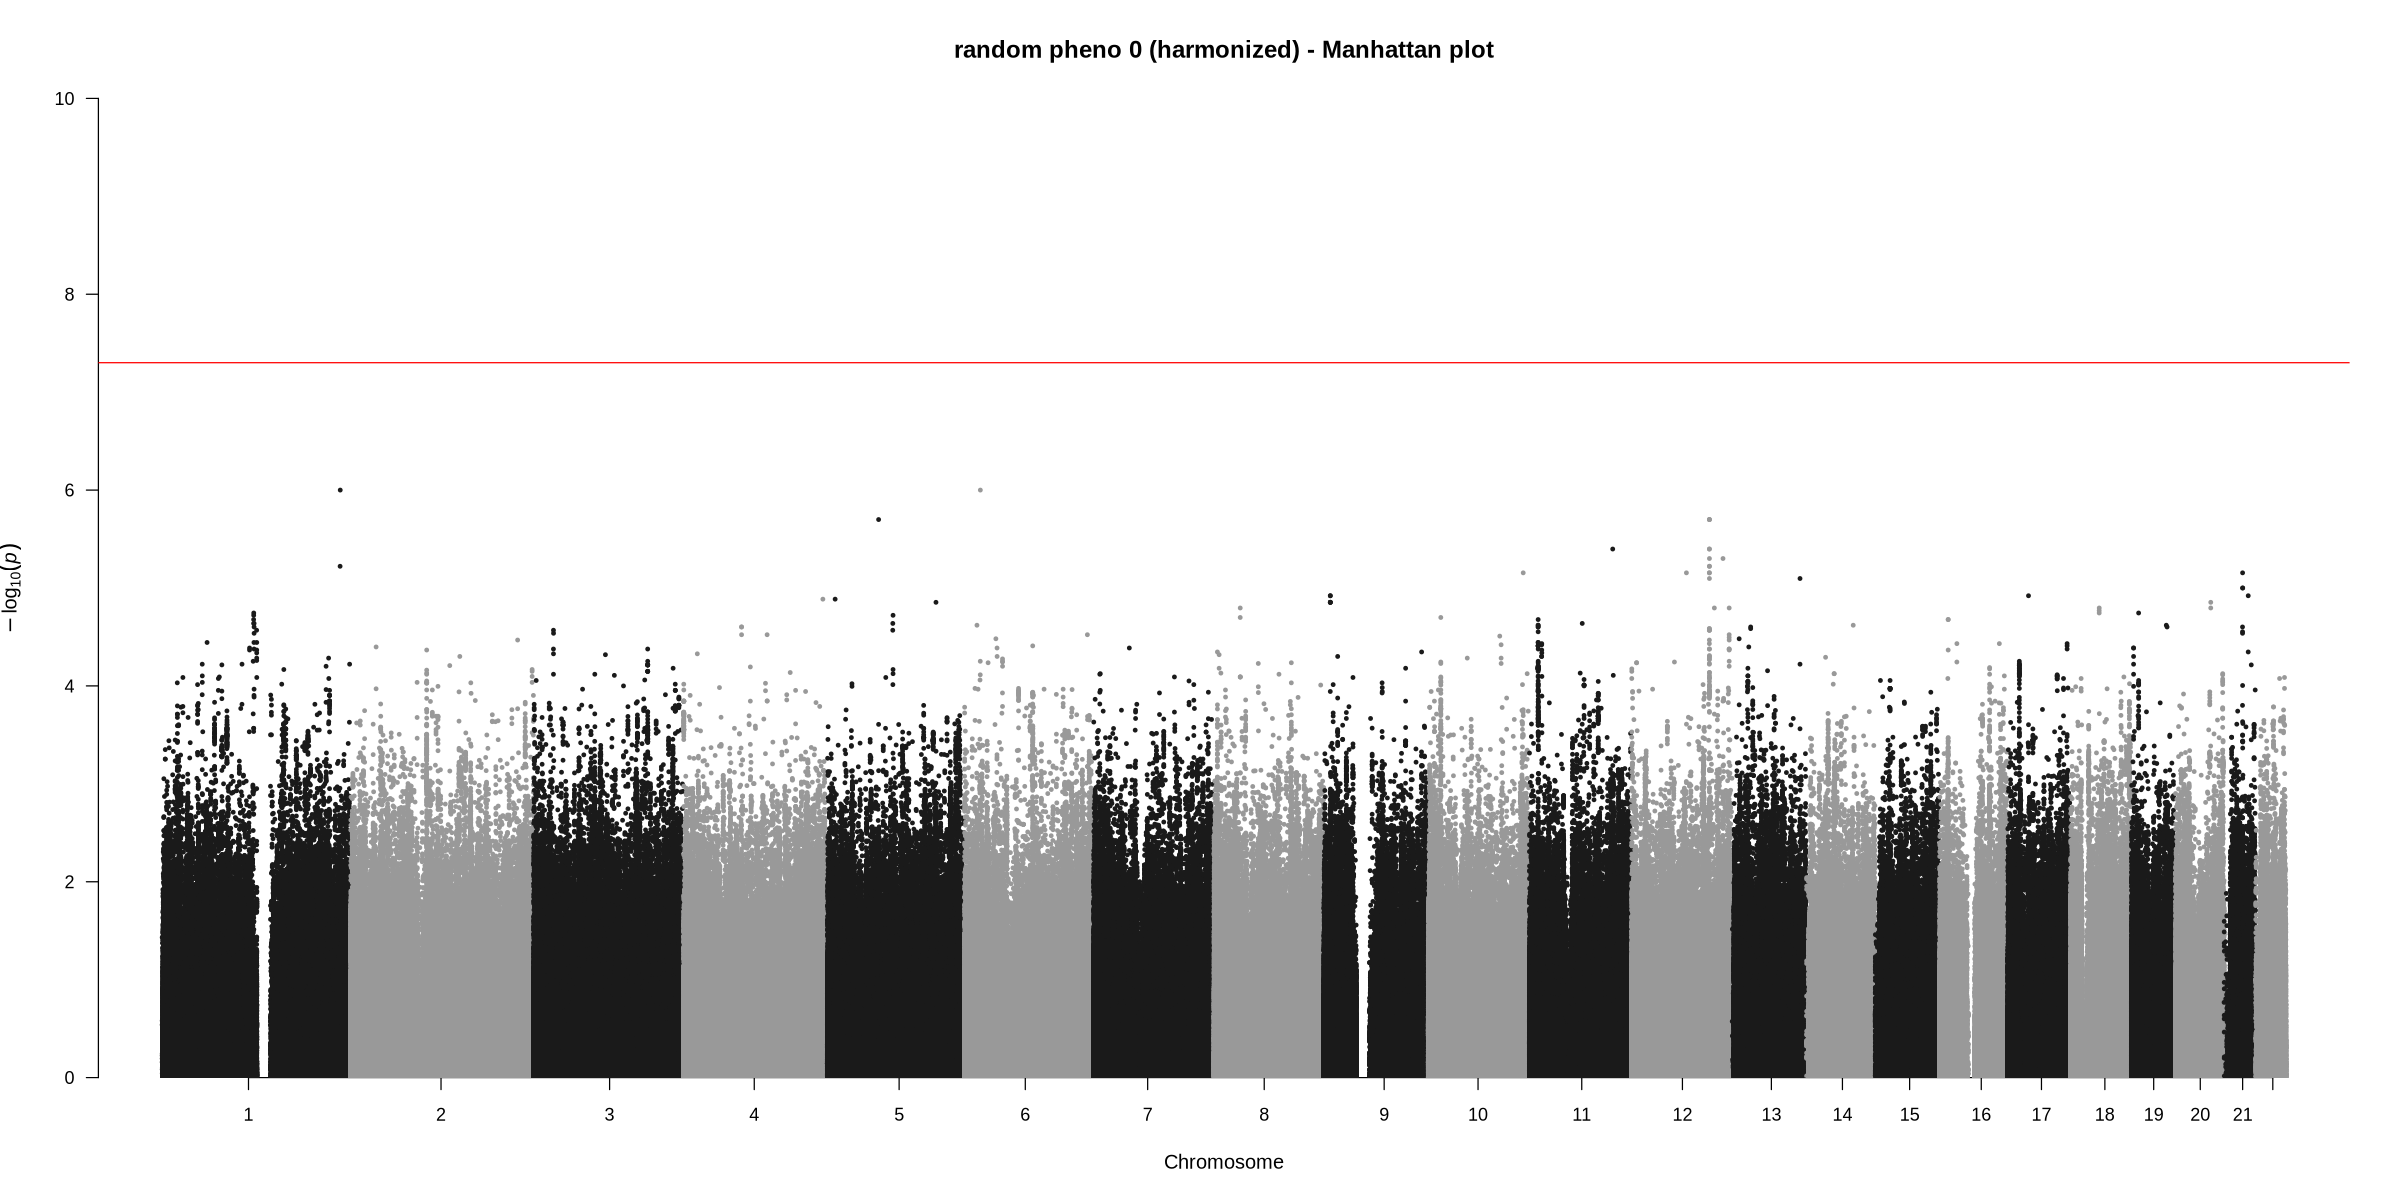

In [27]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

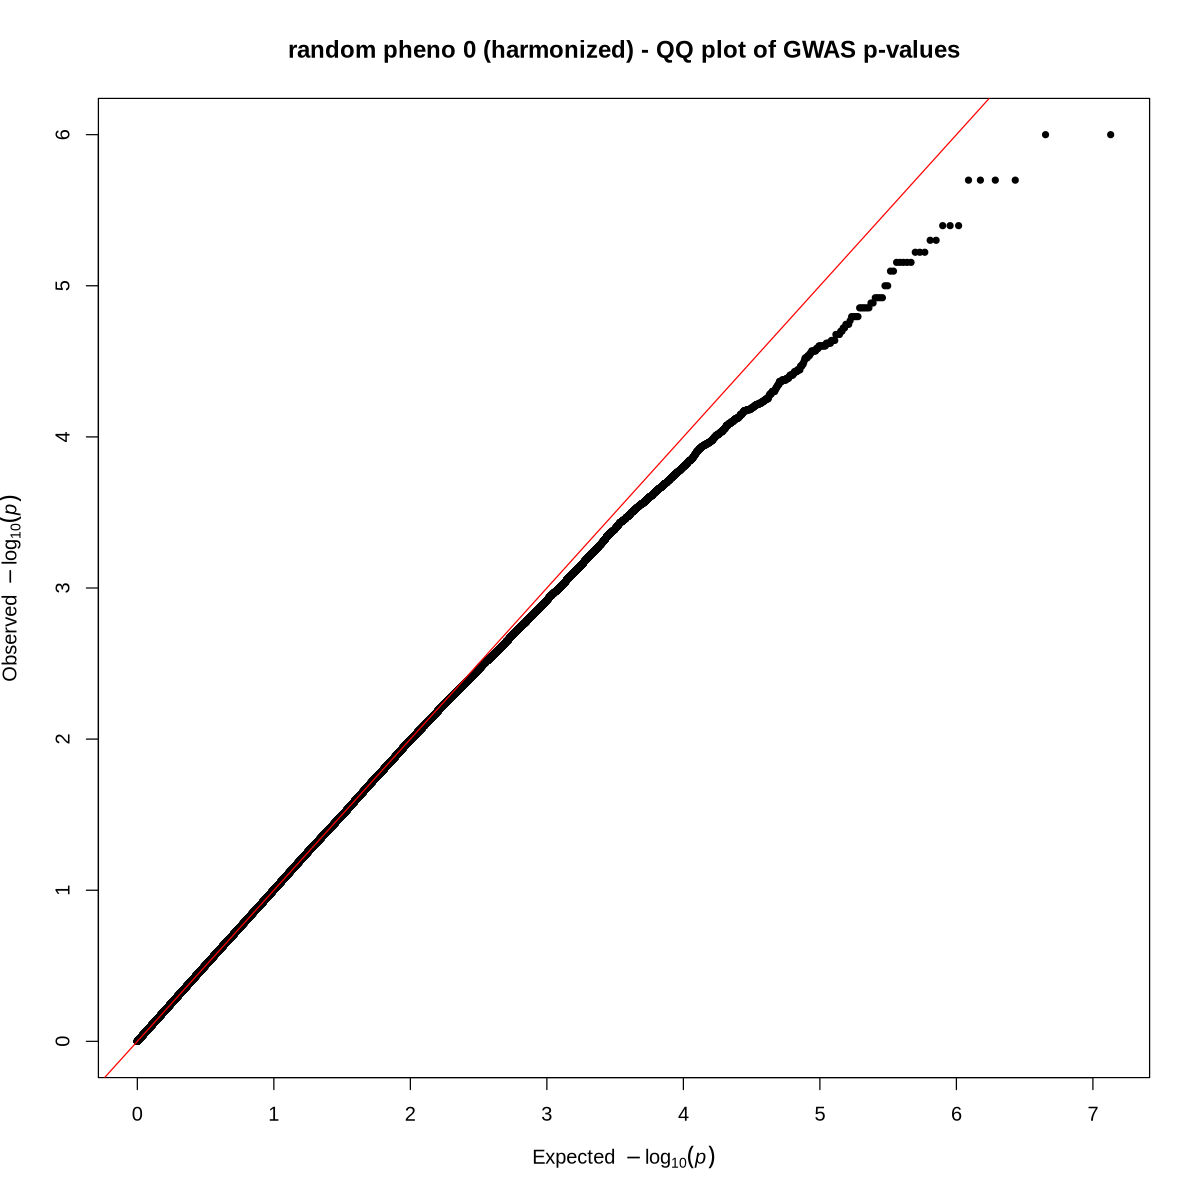

In [28]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 1

In [29]:
pheno_code <- "1"

## Load data

In [30]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [31]:
dim(gwas)

[1] 6746644      13

In [32]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.33876383,0.9566106,0.0642078,0.0671201,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.70816557,0.3743209,0.0251842,0.0672797,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.85284744,0.1854865,0.0109034,0.0587827,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.63299722,0.4775125,0.0225883,0.0473041,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.43481482,0.7809790,0.0534053,0.0683825,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.08060532,1.7471846,0.1305720,0.0747328,10000,NA


### Extract chromosome

In [33]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [34]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [35]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [36]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [37]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.5015598,0.2887063,1.406294e-06,1


In [38]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [39]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.4327883,0.4349653,0,5.851924


In [40]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [41]:
gwas_max_mlog_noninf

[1] 5.851924

In [42]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [43]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.005953832,0.9980677,-4.82411,4.760481


In [44]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [45]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.0001067633,0.03389791,-0.349195,0.311692


In [46]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [47]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.03007558,0.01608604,0.0139249,0.240369


## Manhattan plot

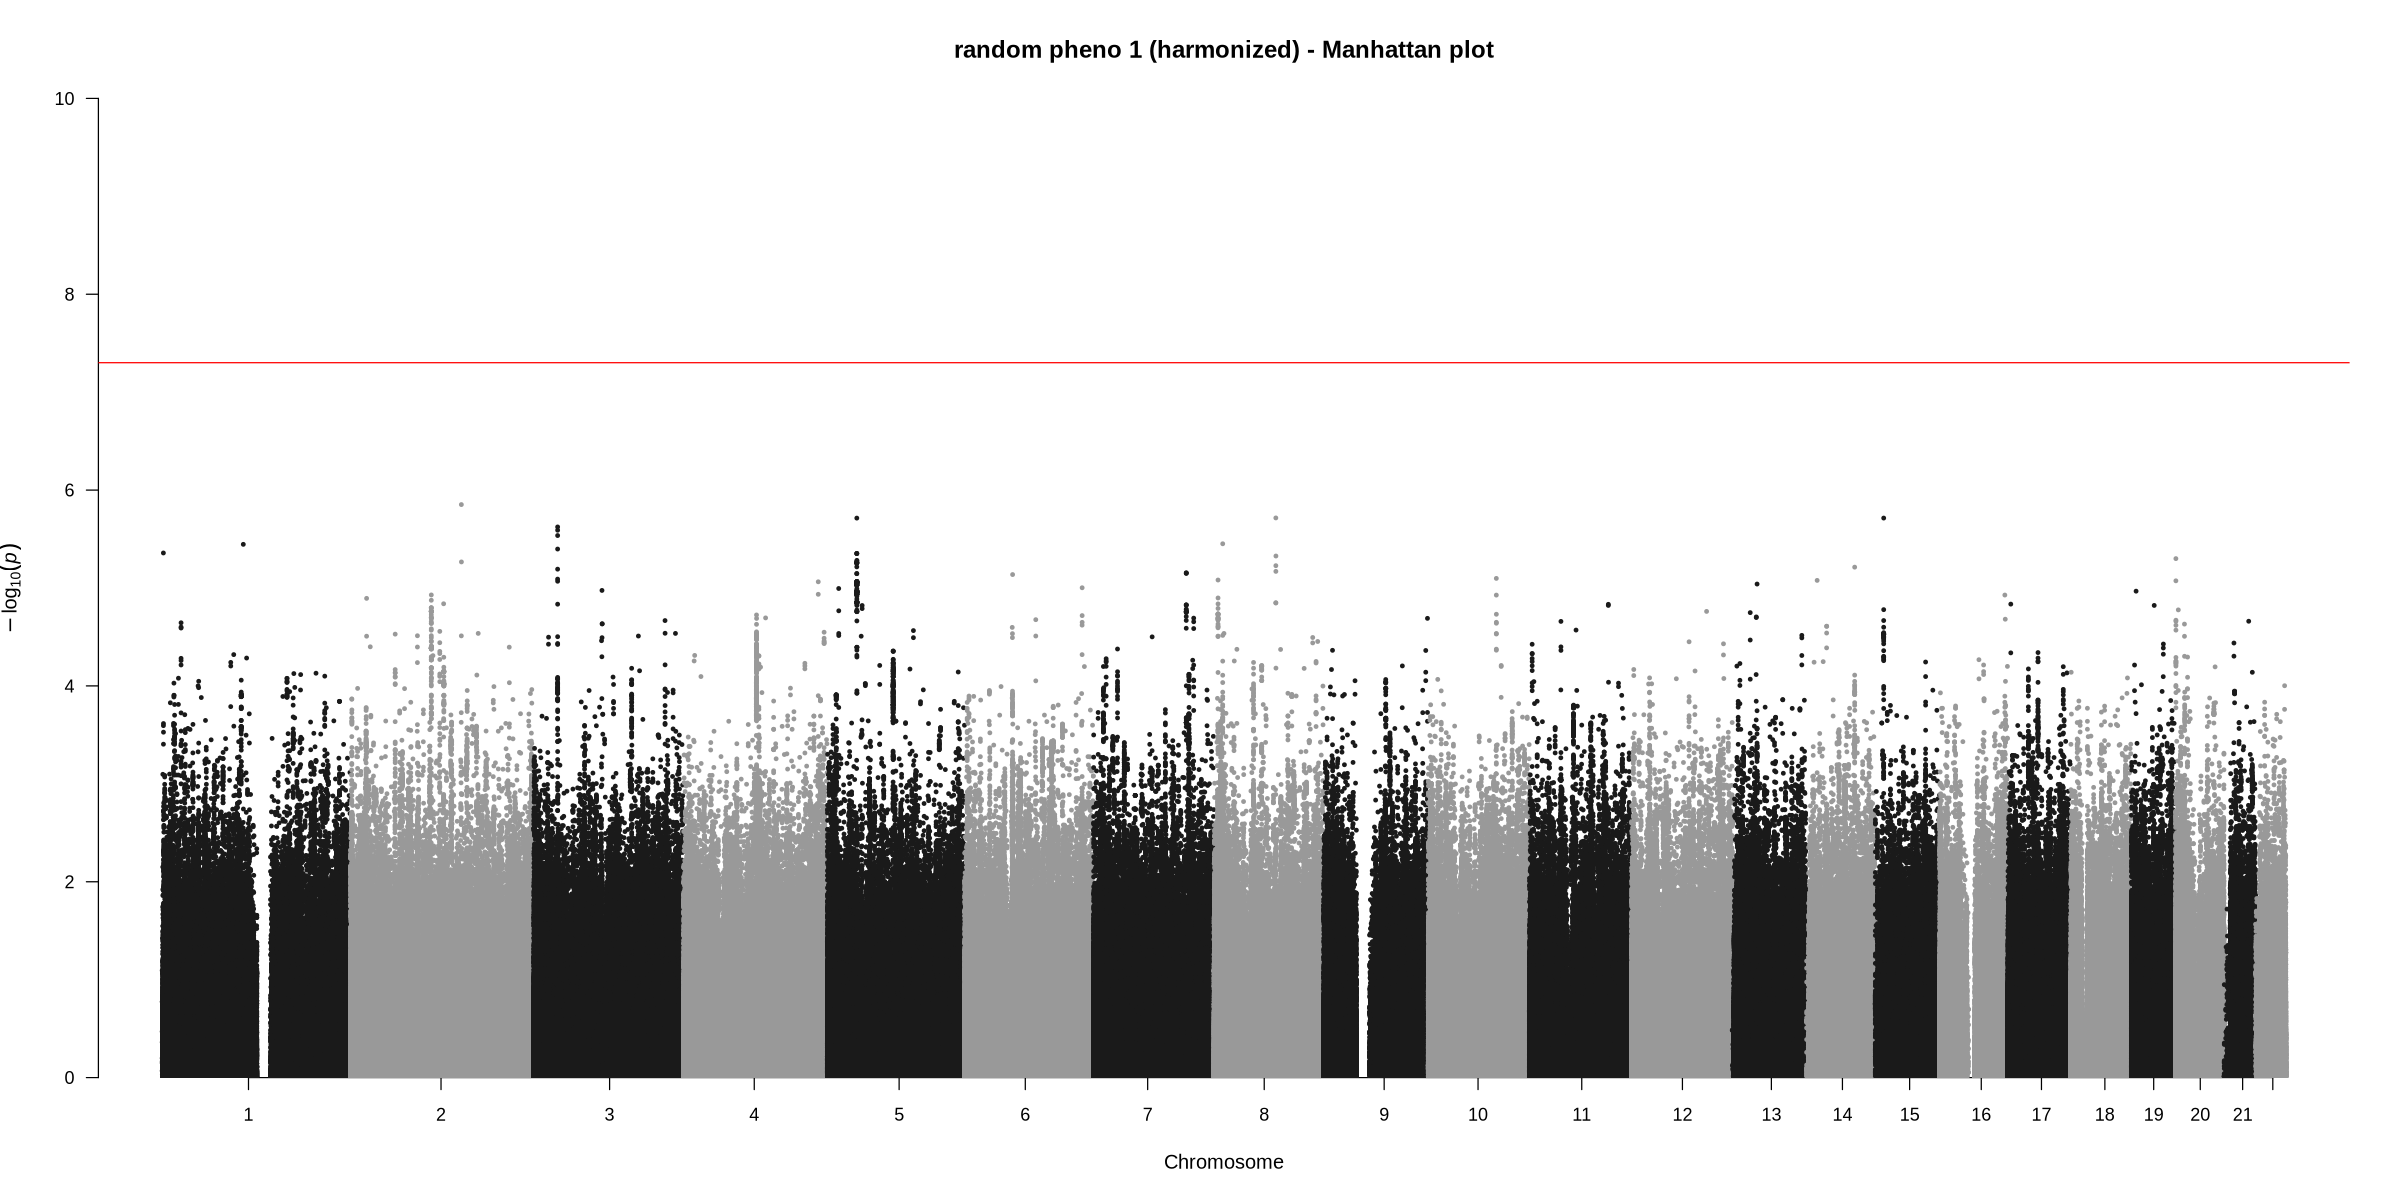

In [48]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

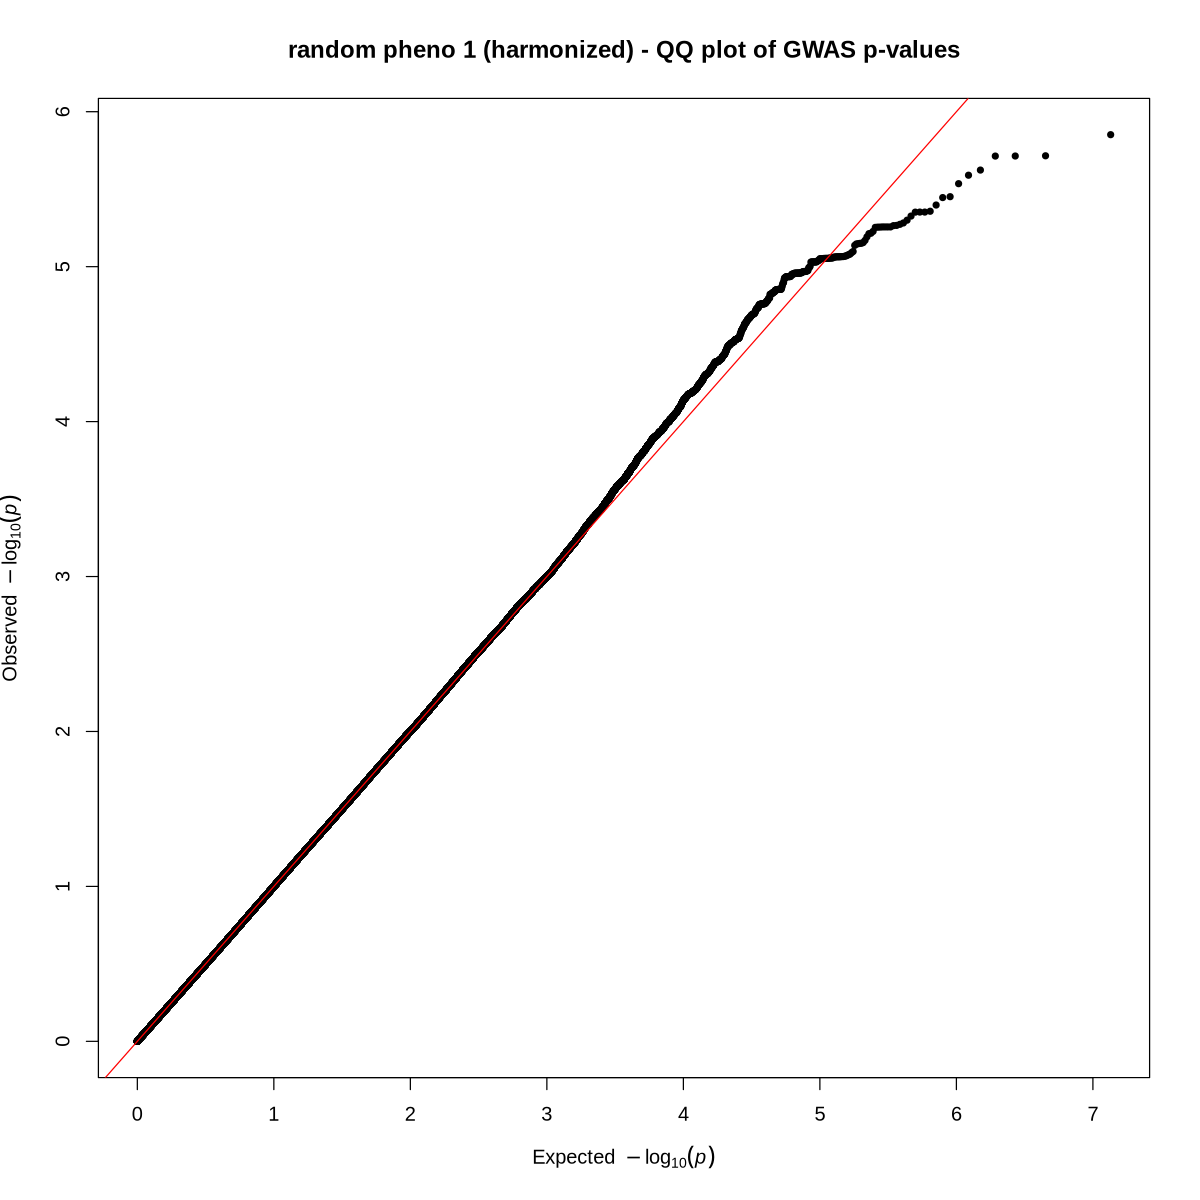

In [49]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 2

In [50]:
pheno_code <- "2"

## Load data

In [51]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [52]:
dim(gwas)

[1] 6746644      13

In [53]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.8538366,0.1842255,0.0123126,0.0668344,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.6743719,0.4201555,0.0281463,0.0669902,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.7672956,0.2959142,0.0173198,0.0585298,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.7883981,-0.2683913,-0.0126415,0.0471010,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.4864197,-0.6960146,-0.0473908,0.0680888,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.7621624,-0.3026424,-0.0225234,0.0744225,10000,NA


### Extract chromosome

In [54]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [55]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [56]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [57]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [58]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.5008433,0.289256,8.64681e-08,1


In [59]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [60]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.4343111,0.4363563,0,7.063144


In [61]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [62]:
gwas_max_mlog_noninf

[1] 7.063144

In [63]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [64]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.001419521,1.000667,-5.353083,5.132811


In [65]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [66]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.0001239126,0.03401235,-0.401993,0.369819


In [67]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [68]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.02994623,0.01601686,0.0138656,0.239336


## Manhattan plot

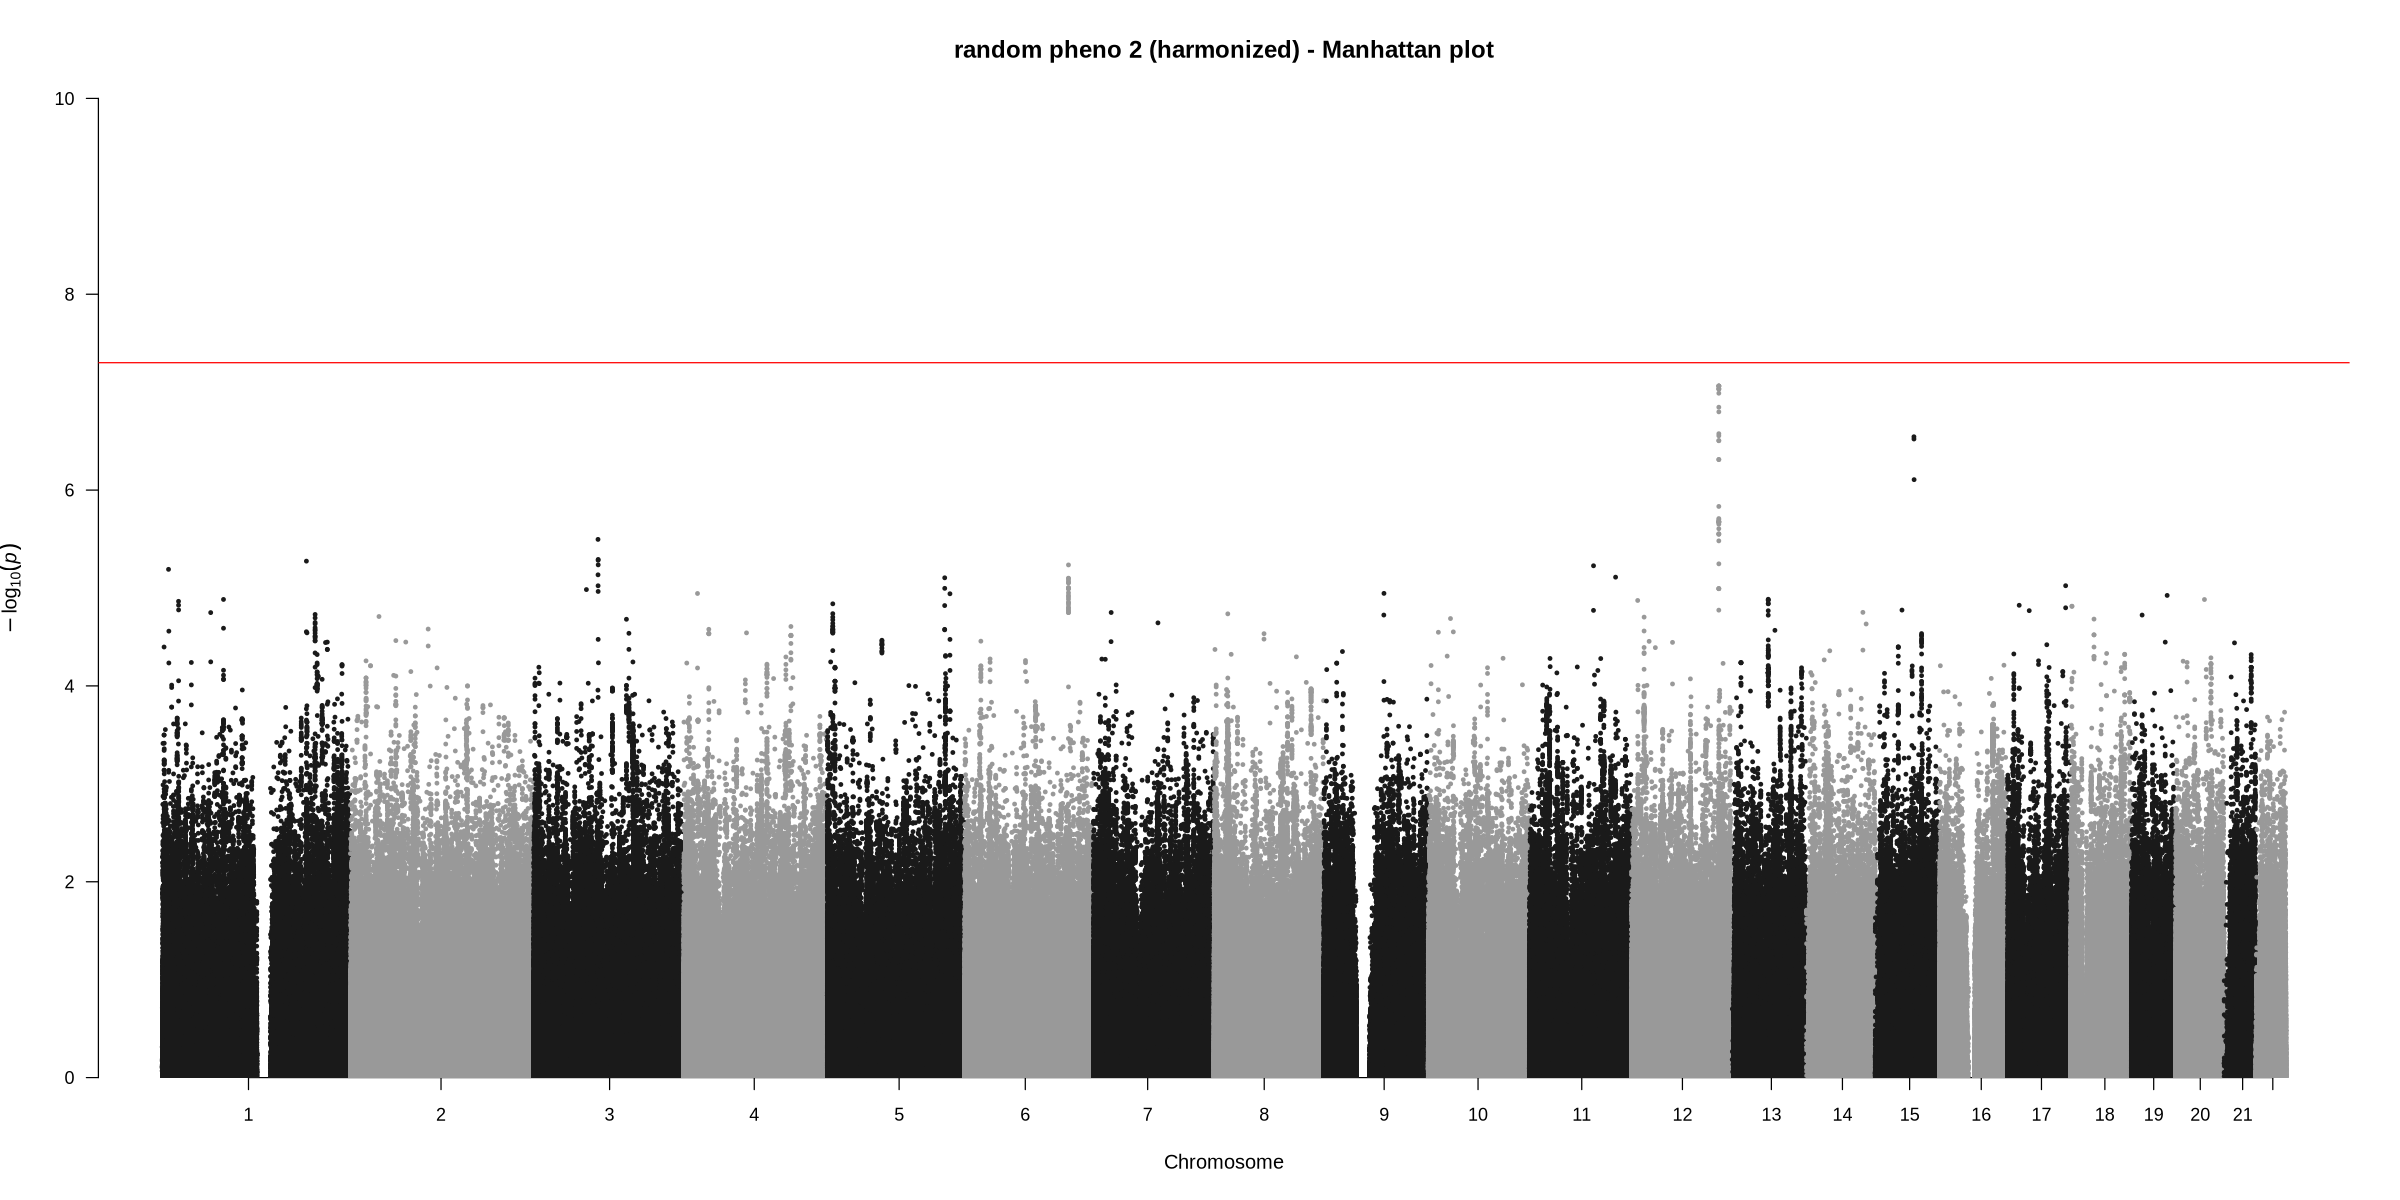

In [69]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

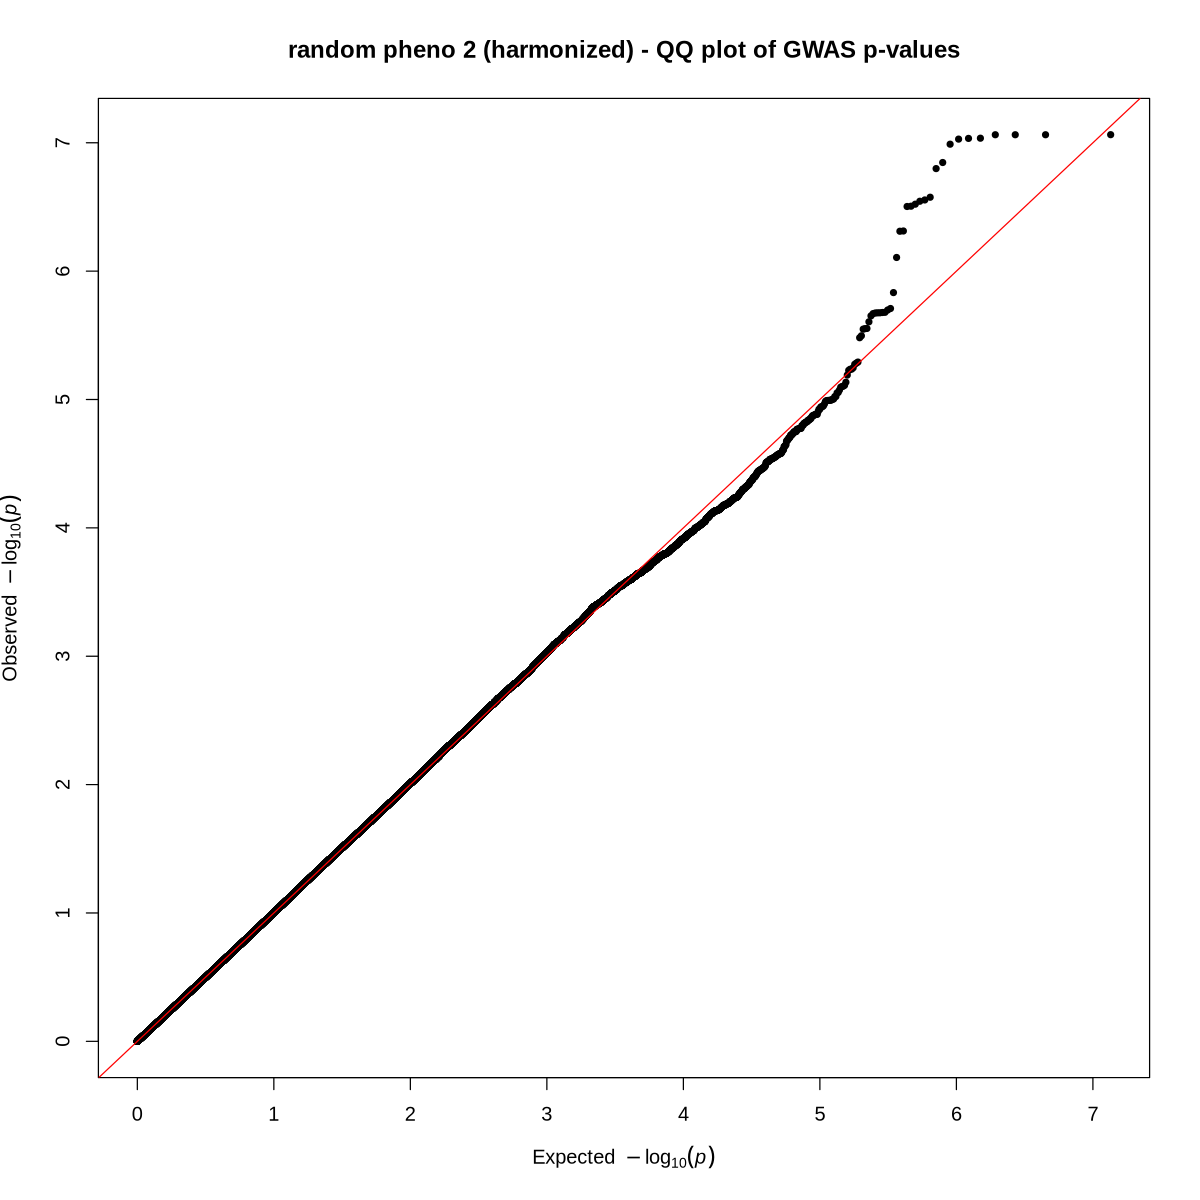

In [70]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 3

In [71]:
pheno_code <- "3"

## Load data

In [72]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [73]:
dim(gwas)

[1] 6746644      13

In [74]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.02189662,-2.2921565,-0.1551540,0.0676891,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.67992319,0.4125679,0.0279988,0.0678647,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.02603534,-2.2256842,-0.1319370,0.0592793,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.49315757,-0.6852953,-0.0326988,0.0477149,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.02751145,-2.2041833,-0.1520060,0.0689625,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.48850688,0.6926856,0.0522233,0.0753925,10000,NA


### Extract chromosome

In [75]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [76]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [77]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [78]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [79]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.4998832,0.2880378,4.515703e-08,1


In [80]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [81]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.4333543,0.4321615,0,7.345275


In [82]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [83]:
gwas_max_mlog_noninf

[1] 7.345275

In [84]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [85]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.001546814,0.9980059,-5.469397,4.974142


In [86]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [87]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-3.70142e-05,0.03433324,-0.389469,0.305006


In [88]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [89]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.03033712,0.01622583,0.0140463,0.242463


## Manhattan plot

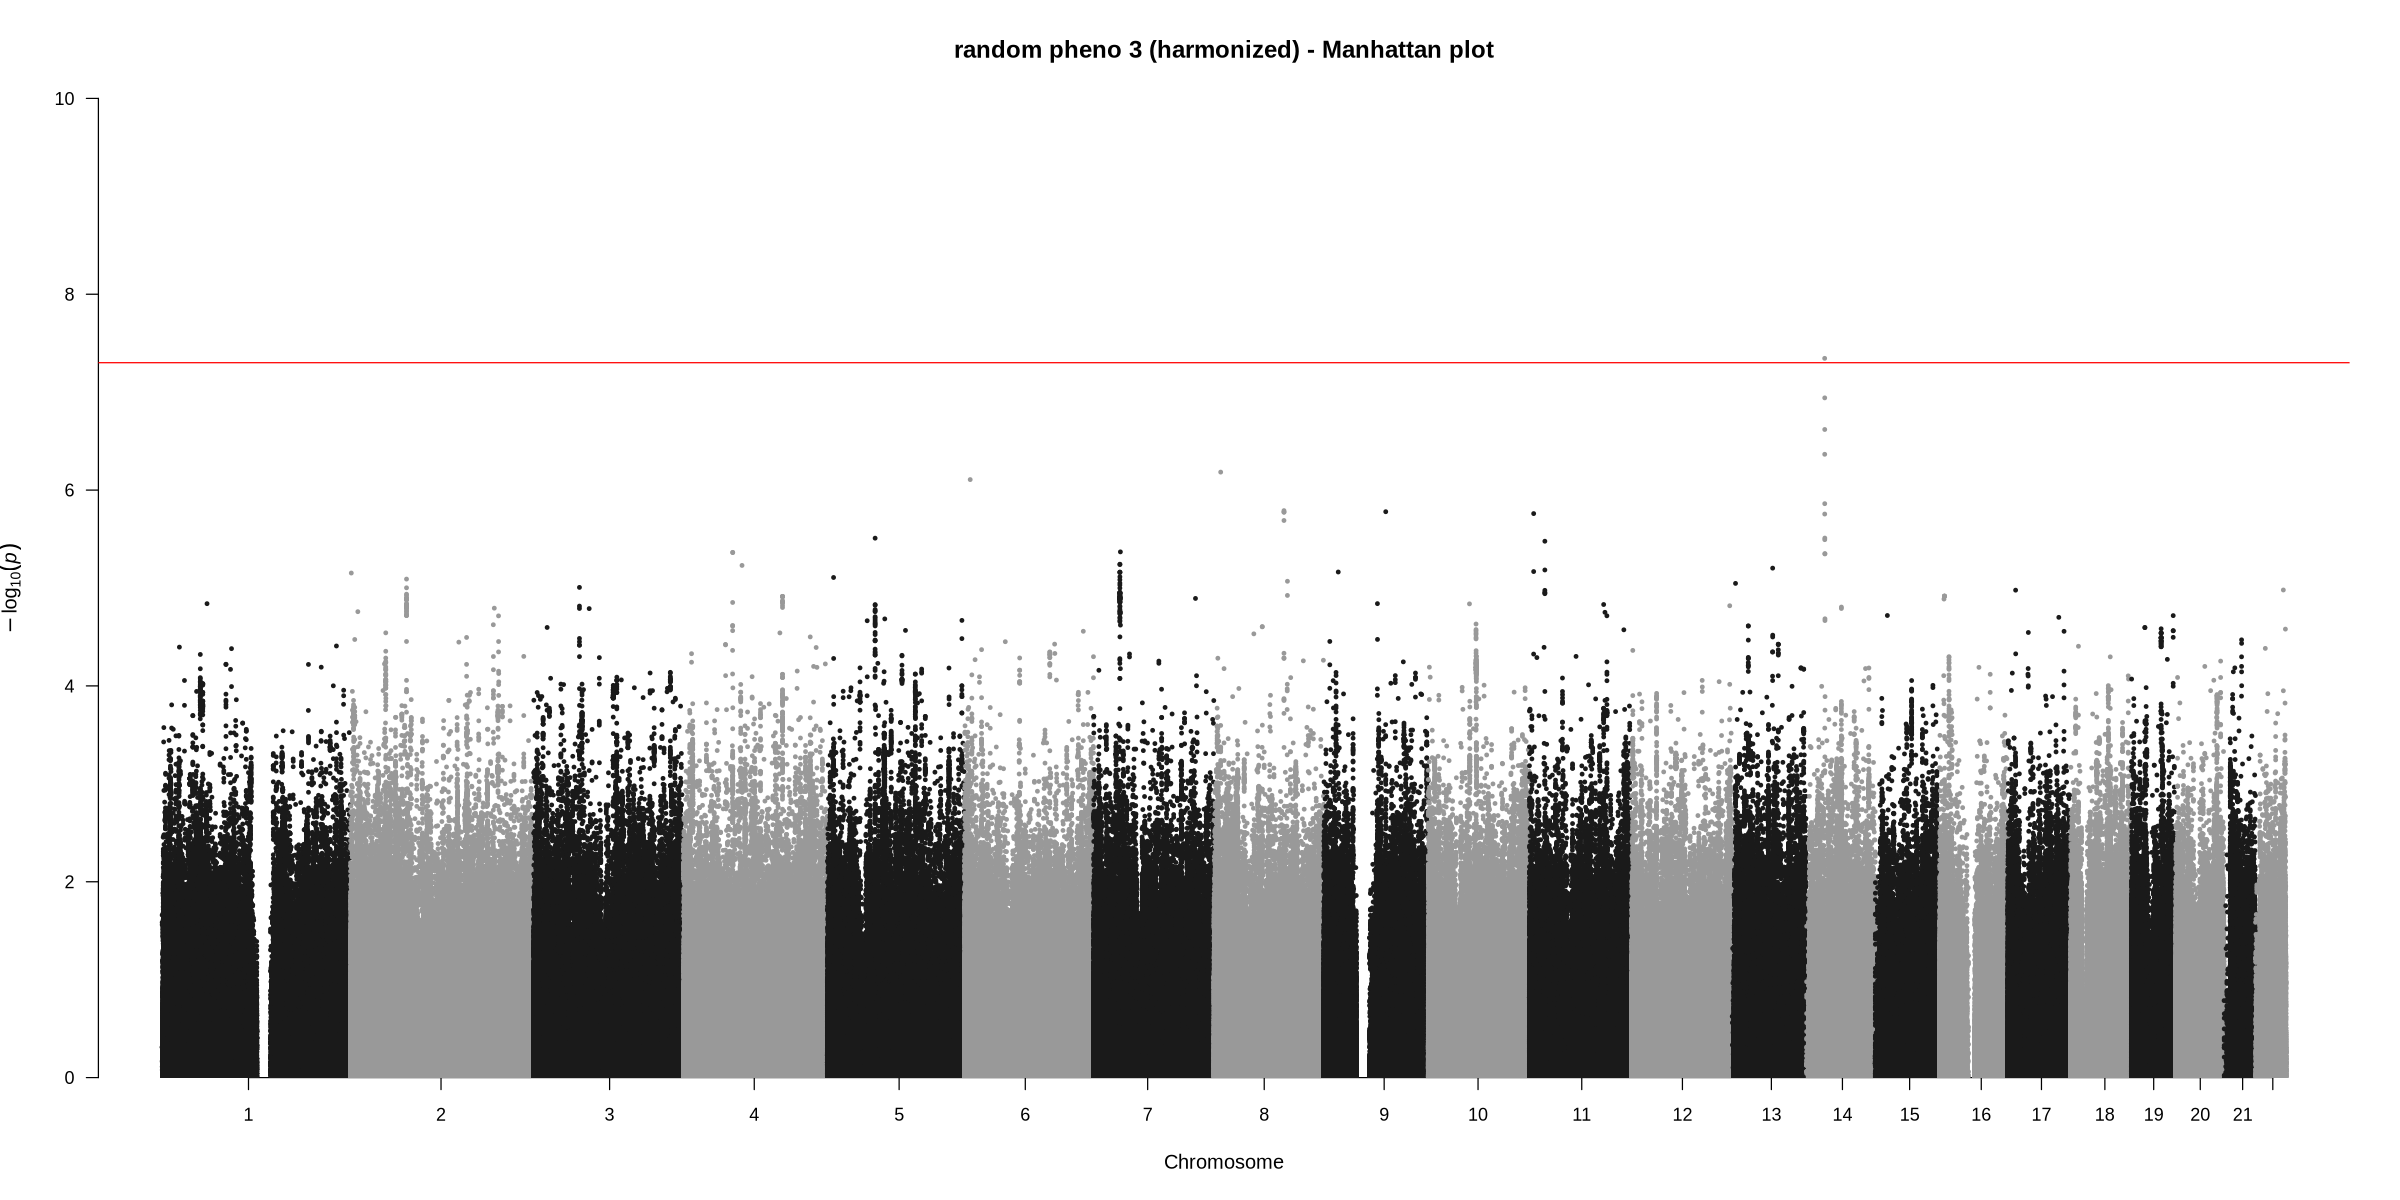

In [90]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

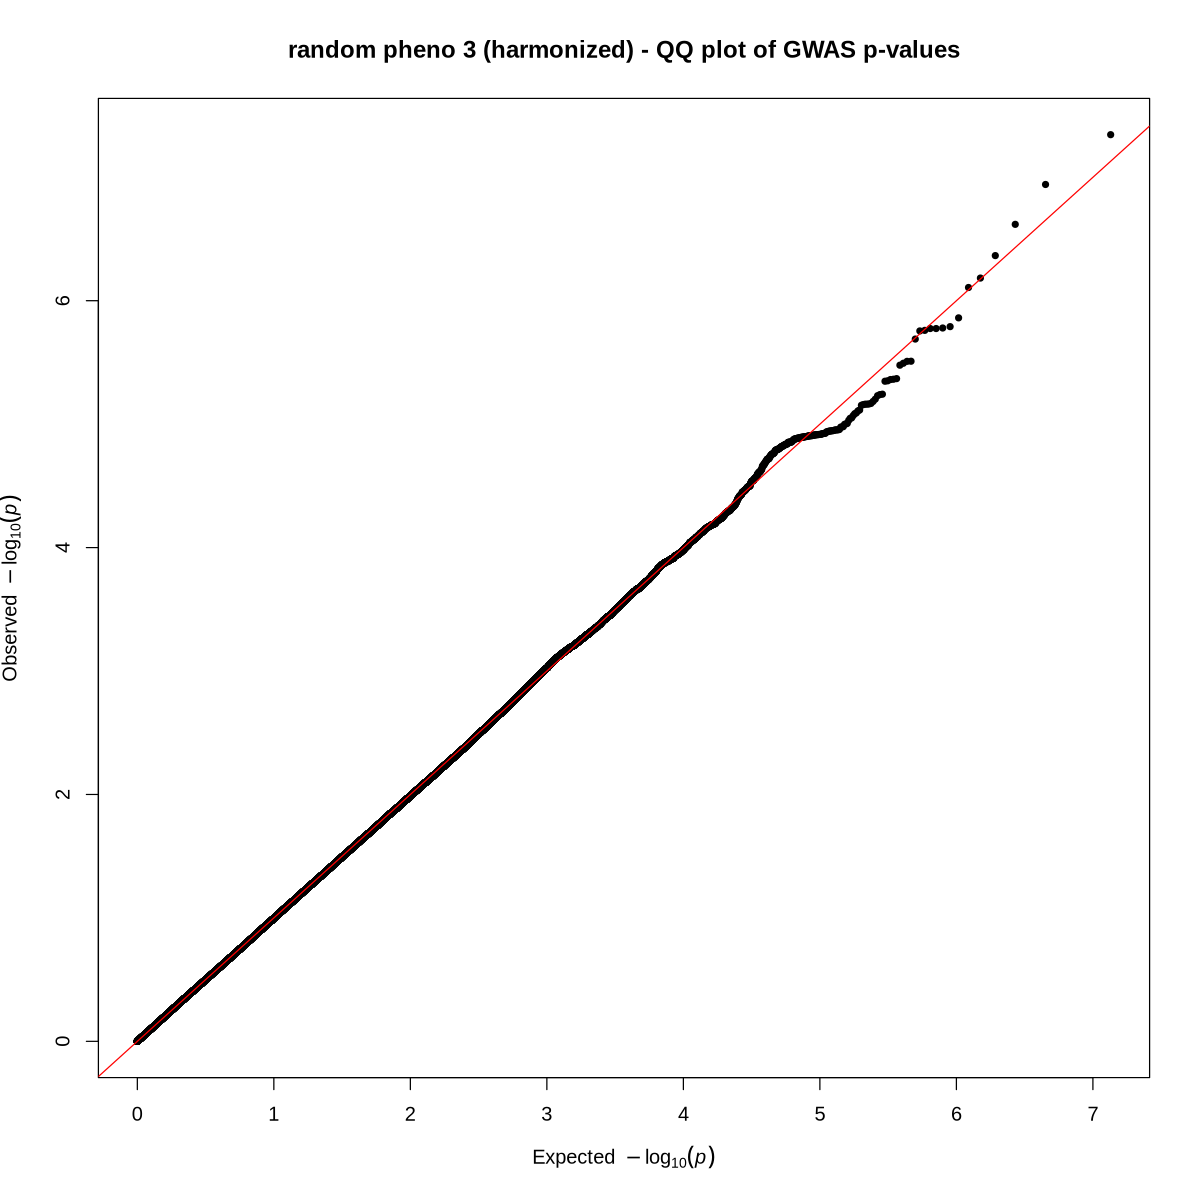

In [91]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 4

In [92]:
pheno_code <- "4"

## Load data

In [93]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv-harmonized.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [94]:
dim(gwas)

[1] 6746644      13

In [95]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.5300662,0.6279050,0.0419875,0.0668692,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.1472752,-1.4492233,-0.0971268,0.0670199,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.8452471,-0.1951863,-0.0114304,0.0585615,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.0106038,-2.5554912,-0.1203920,0.0471111,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.6414267,0.4657049,0.0317268,0.0681264,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.2531981,-1.1426158,-0.0850770,0.0744581,10000,NA


### Extract chromosome

In [96]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [97]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [98]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [99]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [100]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.4994318,0.2893545,1.242639e-06,1


In [101]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [102]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.436745,0.4399467,0,5.905655


In [103]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [104]:
gwas_max_mlog_noninf

[1] 5.905655

In [105]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [106]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-0.006746996,1.004572,-4.848715,4.702232


In [107]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [108]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-0.0002411835,0.03415575,-0.403743,0.358805


In [109]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [110]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.02996227,0.01602547,0.0138731,0.239446


## Manhattan plot

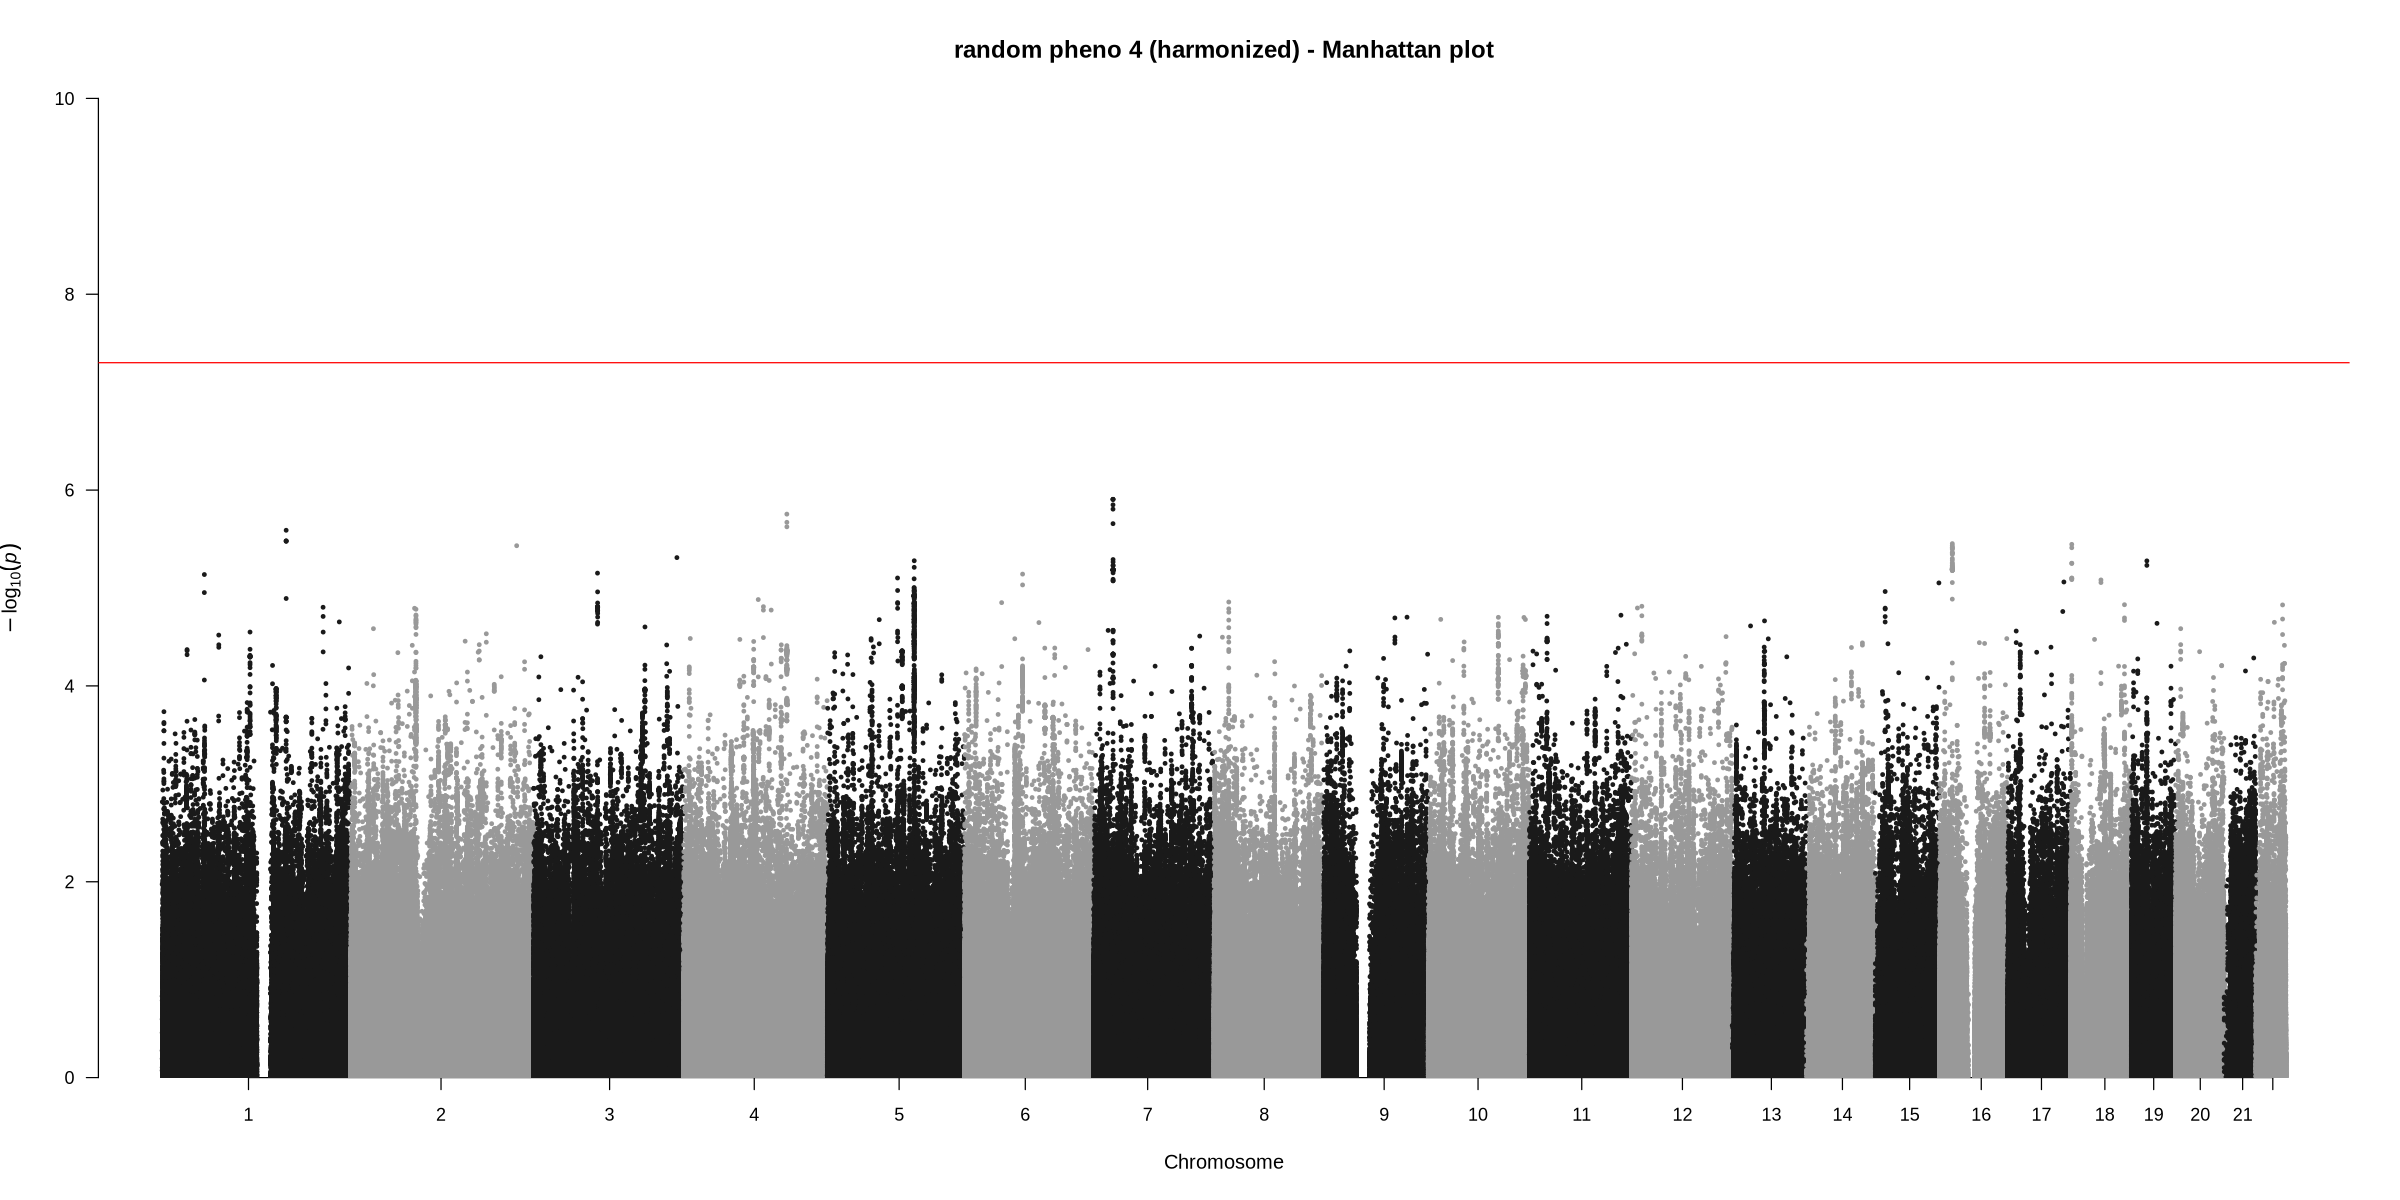

In [111]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

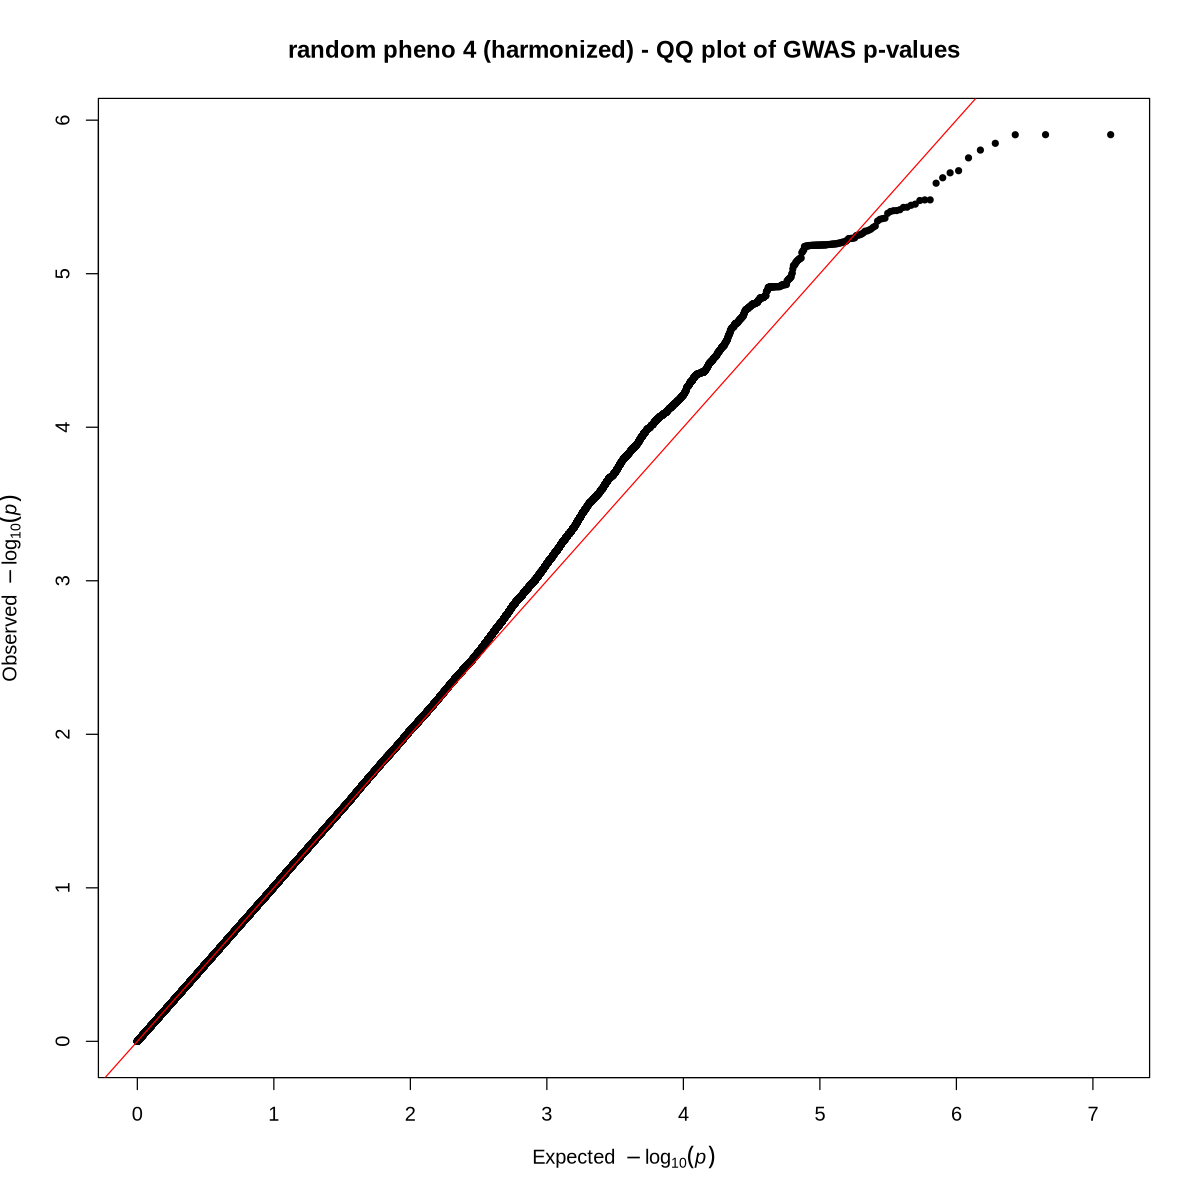

In [112]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)